# Controlled Descent Simulator — the continuous-time LQR solver

*Vehicle-agnostic notebook.* This notebook develops the **Linear-Quadratic
Regulator (LQR)** synthesis used across the simulator — computing the optimal
feedback gain by the **matrix-sign function** of a Hamiltonian matrix —
**independently of any specific vehicle**, validates it on a synthetic
benchmark, and then **conforms it against the hand-written C++** in
`libs/control/lqr.hpp`.

**LQR** (Linear-Quadratic Regulator): for a *linear* plant and a *quadratic*
cost, the optimal controller is a constant linear state feedback `u = -K x`. The
whole job is to compute the gain matrix `K`. Unlike the nonlinear MPC (the iLQR
notebook), this problem is solved **once**, offline — `K` does not change as the
state evolves — which is exactly why a direct, non-iterative synthesis is worth
having.

**Why this notebook exists (methodology).** The vehicle *model* is a symbolic
object, so it is **generated** (SymPy → C++ codegen, see the `model/`
notebooks). The gain synthesis is an **algorithm**, not a formula — there is
nothing to "generate" — so it is **hand-written in C++** as reusable
infrastructure and **validated from Python**. This notebook is the Python side:
the pedagogical derivation (the "spec") and the conformance oracle. The C++ is
the product; the two are pinned together by the conformance cell at the end. It
is the sibling of the iLQR notebook.

> Reading order is linear: every term is defined where it first appears, and no
> quantity is used before it is motivated.

References: Kalman, *Contributions to the theory of optimal control* (1960);
Laub, *A Schur method for solving algebraic Riccati equations* (IEEE TAC 1979);
Roberts, *Linear model reduction and solution of the algebraic Riccati equation
by use of the sign function* (Int. J. Control 1980); Higham, *Functions of
Matrices* (SIAM 2008); Anderson & Moore, *Optimal Control: Linear Quadratic
Methods* (1990).

## 1. The problem: infinite-horizon LQR

We work in **continuous time**. The plant is *linear*,
$$\dot x = A x + B u,\qquad x\in\mathbb{R}^{n_x},\ u\in\mathbb{R}^{n_u},$$
and we choose the command $u(t)$ to minimise the *quadratic* cost
$$ J = \int_0^\infty \big( x^\top Q\,x + u^\top R\,u \big)\,dt, $$
with $Q=Q^\top\succeq 0$ (how much we dislike being off-target) and
$R=R^\top\succ 0$ (how much we dislike effort; strictly positive so *every*
actuator direction costs something and the problem is well posed).

The fundamental LQR result is that the optimal control is a **constant linear
state feedback**
$$ u = -K\,x, $$
for a single gain matrix $K\in\mathbb{R}^{n_u\times n_x}$ that does not depend on
time or on the state — and that the resulting closed loop $\dot x = (A-BK)x$ is
asymptotically stable, i.e. every eigenvalue of $A-BK$ has strictly negative real
part (the matrix is **Hurwitz**). Computing $K$ is the entire task of this
notebook.

This is the core of the vehicle's tracking controller: the real models feed back
the tracking error $x-x_\text{ref}$ (with integrator-augmented states) and add a
feedforward, but the gain $K$ comes from exactly this problem, linearised about
the operating point. Here we treat the generic linear problem; the
vehicle-specific $A,B,Q,R$ live in the `model/` notebooks.

## 2. The cost-to-go and the Riccati equation

Define the **cost-to-go** (or *value function*) $V(x)$ as the smallest cost still
achievable starting from state $x$. For this linear-quadratic problem it is
itself a quadratic form,
$$ V(x) = x^\top X\,x,\qquad X = X^\top \succeq 0, $$
for some symmetric matrix $X$ we must determine. Its gradient is
$\nabla V(x) = 2Xx$ (we write $\nabla V \equiv \partial V/\partial x$, the vector
of partial derivatives).

**Bellman / Hamilton–Jacobi stationarity** says that along the optimal path the
running cost is exactly balanced by the rate at which the cost-to-go is spent:
$$ 0 = \min_{u}\Big[\; x^\top Q x + u^\top R u + \nabla V(x)^\top (Ax+Bu) \;\Big]. $$
The bracket is quadratic in $u$; setting its $u$-gradient
$2Ru + 2B^\top X x$ to zero gives the minimiser
$$ u^\star = -R^{-1}B^\top X\,x \;\equiv\; -K x, \qquad \boxed{\,K = R^{-1}B^\top X\,}. $$
So *once we know $X$, the gain is immediate.* Substituting $u^\star$ back into the
bracket and demanding the identity hold for all $x$ collapses to a matrix
equation in $X$ — the **Continuous-time Algebraic Riccati Equation (CARE)**:
$$ \boxed{\,A^\top X + X A - X B R^{-1} B^\top X + Q = 0.\,} $$

The CARE is *quadratic* in the unknown $X$ (the term $-XBR^{-1}B^\top X$), so it
has more than one solution. We want the unique **stabilising** one: the
$X\succeq0$ for which $A-BK = A-BR^{-1}B^\top X$ is Hurwitz. The rest of the
notebook is a robust way to select *that* solution.

## 3. The Hamiltonian and its stable subspace

Abbreviate $G = B R^{-1} B^\top$ (symmetric, $\succeq 0$). Assemble the
$2n_x \times 2n_x$ **Hamiltonian matrix**
$$ H = \begin{bmatrix} A & -G \\ -Q & -A^\top \end{bmatrix}. $$
Two properties make it the right object to work with.

**1. Spectral symmetry.** $H$ is a *Hamiltonian matrix*: with
$J=\left[\begin{smallmatrix}0&I\\-I&0\end{smallmatrix}\right]$ one has
$(JH)^\top = JH$. This forces the spectrum to be symmetric about the imaginary
axis — if $\mu$ is an eigenvalue, so is $-\mu$. Under mild conditions
(stabilisability of $(A,B)$ and detectability of $(A,Q^{1/2})$) *no* eigenvalue
lies on the axis, so exactly $n_x$ of them have $\operatorname{Re}\mu<0$ (call
these the **stable** ones) and $n_x$ have $\operatorname{Re}\mu>0$.

**2. The graph of $X$ is an invariant subspace.** Suppose the columns of
$\left[\begin{smallmatrix}I\\X\end{smallmatrix}\right]$ span an $H$-invariant
subspace — i.e. $H\left[\begin{smallmatrix}I\\X\end{smallmatrix}\right]
= \left[\begin{smallmatrix}I\\X\end{smallmatrix}\right] M$ for some
$n_x\times n_x$ matrix $M$. Expanding the two block rows,
$$ A - G X = M, \qquad -Q - A^\top X = X M. $$
Substituting the first into the second eliminates $M$ and reproduces the CARE
exactly. And since $M = A - G X = A - B K$ is the closed-loop matrix, choosing
the **stable** invariant subspace (eigenvalues of $M$ in the left half-plane)
makes the closed loop Hurwitz — i.e. yields the stabilising $X$.

So the plan is concrete: *find the stable invariant subspace of $H$, write its
basis as $[I;X]$, and read off $X$.* The matrix-sign function delivers that
subspace directly.

## 4. The matrix-sign function

For a matrix $Z$ with no eigenvalue on the imaginary axis, the **matrix-sign
function** $\operatorname{sign}(Z)$ replaces every eigenvalue $\mu$ by
$\operatorname{sign}(\operatorname{Re}\mu)=\pm1$ while keeping the eigenvectors:
if $Z = V\Lambda V^{-1}$ then
$\operatorname{sign}(Z) = V\,\operatorname{diag}(\pm1)\,V^{-1}$.

Applied to the Hamiltonian, $S:=\operatorname{sign}(H)$ has eigenvalue $-1$ on
the stable subspace ($\operatorname{Re}\mu<0$) and $+1$ on the unstable one.
Therefore the **stable subspace is the kernel of $S+I$** — exactly the subspace
§3 asked for.

<svg xmlns="http://www.w3.org/2000/svg" width="560" height="210" viewBox="0 0 560 210">
  <rect width="560" height="210" fill="#ffffff"/>
  <text x="280" y="20" font-family="serif" font-size="14" font-style="italic" text-anchor="middle" fill="#111">sign(&#183;) collapses the &#177;-symmetric Hamiltonian spectrum onto {&#8722;1, +1}</text>
  <!-- LEFT: complex plane of H -->
  <line x1="30" y1="120" x2="250" y2="120" stroke="#111" stroke-width="1"/>
  <line x1="140" y1="45" x2="140" y2="195" stroke="#111" stroke-width="1"/>
  <text x="255" y="124" font-family="serif" font-size="12" fill="#111">Re</text>
  <text x="145" y="55" font-family="serif" font-size="12" fill="#111">Im</text>
  <text x="140" y="210" font-family="serif" font-size="12" text-anchor="middle" fill="#555">spectrum of H</text>
  <!-- stable eigenvalues (left, Re<0) blue -->
  <circle cx="80" cy="95" r="4" fill="#1f6feb"/>
  <circle cx="95" cy="150" r="4" fill="#1f6feb"/>
  <circle cx="70" cy="120" r="4" fill="#1f6feb"/>
  <!-- unstable eigenvalues (right, Re>0) red, mirror images -->
  <circle cx="200" cy="95" r="4" fill="#d1242f"/>
  <circle cx="185" cy="150" r="4" fill="#d1242f"/>
  <circle cx="210" cy="120" r="4" fill="#d1242f"/>
  <text x="70" y="85" font-family="serif" font-size="10" fill="#1f6feb">stable</text>
  <text x="188" y="85" font-family="serif" font-size="10" fill="#d1242f">unstable</text>
  <!-- ARROW -->
  <line x1="270" y1="120" x2="330" y2="120" stroke="#111" stroke-width="1.5" marker-end="url(#ah)"/>
  <defs><marker id="ah" markerWidth="9" markerHeight="9" refX="7" refY="3" orient="auto"><path d="M0,0 L7,3 L0,6 z" fill="#111"/></marker></defs>
  <text x="300" y="112" font-family="serif" font-size="13" text-anchor="middle" fill="#111">sign</text>
  <!-- RIGHT: spectrum of sign(H) = {-1,+1} -->
  <line x1="360" y1="120" x2="540" y2="120" stroke="#111" stroke-width="1"/>
  <line x1="450" y1="45" x2="450" y2="195" stroke="#111" stroke-width="1"/>
  <circle cx="400" cy="120" r="5" fill="#1f6feb"/>
  <circle cx="500" cy="120" r="5" fill="#d1242f"/>
  <text x="392" y="145" font-family="serif" font-size="12" fill="#1f6feb">&#8722;1</text>
  <text x="495" y="145" font-family="serif" font-size="12" fill="#d1242f">+1</text>
  <text x="450" y="210" font-family="serif" font-size="12" text-anchor="middle" fill="#555">spectrum of sign(H)</text>
  <text x="450" y="70" font-family="serif" font-size="11" text-anchor="middle" fill="#111">stable subspace = ker(S + I)</text>
</svg>

**Computing $\operatorname{sign}(Z)$.** It is the limit of Newton's iteration
for $S^2=I$ applied eigenvalue-by-eigenvalue,
$$ Z_{k+1} = \tfrac12\big(Z_k + Z_k^{-1}\big),\qquad Z_0 = Z, $$
which converges *quadratically*. The early iterations are accelerated by a scalar
**Higham scaling** $c_k=\big(\lVert Z_k^{-1}\rVert_F/\lVert Z_k\rVert_F\big)^{1/2}$,
giving $Z_{k+1}=\tfrac12\big(c_kZ_k+(c_kZ_k)^{-1}\big)$ with $c_k\to1$ near the
solution ($\lVert\cdot\rVert_F$ is the Frobenius norm). Each step costs one dense
inverse of a $2n_x\times2n_x$ matrix — cheap, and done **once** at setup.

**Extracting $X$.** Partition $S=\operatorname{sign}(H)$ into $n_x\times n_x$
blocks $\left[\begin{smallmatrix}S_{11}&S_{12}\\S_{21}&S_{22}\end{smallmatrix}\right]$.
The basis $[I;X]$ of $\ker(S+I)$ obeys $(S+I)\left[\begin{smallmatrix}I\\X\end{smallmatrix}\right]=0$,
whose two block rows are
$$ (S_{11}+I) + S_{12}X = 0,\qquad S_{21} + (S_{22}+I)X = 0. $$
Stacked, this is an overdetermined linear system
$\;[\,S_{12};\,S_{22}+I\,]\,X = -[\,S_{11}+I;\,S_{21}\,]\;$ that we solve in the
least-squares sense and then symmetrise (the true $X$ is symmetric). Finally
$K=R^{-1}B^\top X$. This is Roberts' (1980) sign-function route to the CARE; the
classical alternative is Laub's (1979) Schur method — the *same* stable subspace,
reached by a different factorisation.

## 5. A vehicle-agnostic Python reference

The reference implementation is packaged in **`lqr_ref.py`** (next to this
notebook) — the *single source* of the Python synthesis, mirroring the C++ in
`libs/control/lqr.hpp` one-for-one. Packaging it as a module (rather than
re-typing it here) lets the *same* code be reused elsewhere and keeps this
notebook focused on the *why*.

Its public surface — all mirrored in the C++:

- `matrix_sign(Z)` → `S` — the scaled-Newton sign iteration (§4);
- `hamiltonian(A, B, Q, R)` → `H` — the Hamiltonian of §3;
- `care(A, B, Q, R)` → `X` — the stabilising Riccati solution;
- `lqr(A, B, Q, R)` → `K, X` — the optimal gain and the Riccati solution;
- `care_residual(A, B, Q, R, X)` → the CARE left-hand side, for acid tests.

It knows nothing about vehicles: the caller passes the plant $(A,B)$ and the
weights $(Q,R)$.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))     # lqr_ref.py sits next to this notebook
import numpy as np
from lqr_ref import matrix_sign, hamiltonian, care, lqr, care_residual
print('imported the reference synthesis from lqr_ref.py')

imported the reference synthesis from lqr_ref.py


### 5.1 Acid test — the synthesis against an independent oracle (many points)

A single lucky system proves nothing, so we check a *batch* of random plants. For
each we verify two things: that $X$ actually solves the CARE (residual
$\approx0$, an implementation-independent optimality condition), and that the gain
matches `scipy.linalg.solve_continuous_are` — a completely separate
implementation. We also confirm every closed loop is Hurwitz.

In [2]:
import scipy.linalg as sla

rng = np.random.default_rng(0)
worst_res = worst_scipy = 0.0
for _ in range(12):
    n = int(rng.integers(2, 7)); m = int(rng.integers(1, n + 1))
    A = rng.normal(size=(n, n)); B = rng.normal(size=(n, m))
    Qh = rng.normal(size=(n, n)); Q = Qh @ Qh.T + 0.1*np.eye(n)   # symmetric PSD
    Rh = rng.normal(size=(m, m)); R = Rh @ Rh.T + 0.1*np.eye(m)   # symmetric PD
    K, X = lqr(A, B, Q, R)
    worst_res = max(worst_res, np.abs(care_residual(A, B, Q, R, X)).max())
    Xsp = sla.solve_continuous_are(A, B, Q, R); Ksp = np.linalg.solve(R, B.T @ Xsp)
    worst_scipy = max(worst_scipy, np.abs(K - Ksp).max())
    assert np.all(np.linalg.eigvals(A - B @ K).real < 0)          # closed loop Hurwitz

print("acid test over 12 random systems (n = 2..6, m = 1..n):")
print(f"  worst CARE residual |A'X + XA - XGX + Q|   = {worst_res:.2e}")
print(f"  worst |K_ref - K_scipy| (independent oracle) = {worst_scipy:.2e}")
print("  every closed loop A - BK is Hurwitz          = OK")

acid test over 12 random systems (n = 2..6, m = 1..n):
  worst CARE residual |A'X + XA - XGX + Q|   = 1.49e-12
  worst |K_ref - K_scipy| (independent oracle) = 2.01e-13
  every closed loop A - BK is Hurwitz          = OK


## 6. A synthetic benchmark (meaningless by design)

To exercise the *synthesis* — not to model anything — we use three second-order
channels $[p_i, v_i]$ coupled in a ring, with **two channels made open-loop
unstable** (negative damping) so the gain has real stabilising work to do. One
bounded-free actuator drives each channel. The *exact same* system is built in
`libs/control/bind/lqr_conformance.py` and handed to the C++ shim in §7, so we
compare like with like.

In [3]:
OMEGA = np.array([1.3, 0.8, 1.7]); ZETA = np.array([-0.10, 0.05, -0.08])  # 2 unstable
GAIN  = np.array([1.0, 1.2, 0.9]);   KAPPA = 0.4
NX, NU = 6, 3

def build_system():
    A = np.zeros((NX, NX)); B = np.zeros((NX, NU))
    for i in range(3):
        pi, vi, ni = 2*i, 2*i + 1, 2*((i + 1) % 3)
        A[pi, vi] = 1.0
        A[vi, pi] = -OMEGA[i]**2 - KAPPA
        A[vi, vi] = -2*ZETA[i]*OMEGA[i]            # negative ZETA -> unstable
        A[vi, ni] += KAPPA
        B[vi, i]  = GAIN[i]
    Q = np.diag(np.array([3.0, 0.5] * 3))          # position/velocity weights
    R = np.diag([0.08, 0.12, 0.10])
    return A, B, Q, R

A, B, Q, R = build_system()
print("A =\n", np.round(A, 2))
print("open-loop eigenvalues (real parts):", np.round(sorted(np.linalg.eigvals(A).real), 3))

A =
 [[ 0.    1.    0.    0.    0.    0.  ]
 [-2.09  0.26  0.4   0.    0.    0.  ]
 [ 0.    0.    0.    1.    0.    0.  ]
 [ 0.    0.   -1.04 -0.08  0.4   0.  ]
 [ 0.    0.    0.    0.    0.    1.  ]
 [ 0.4   0.    0.    0.   -3.29  0.27]]
open-loop eigenvalues (real parts): [-0.035 -0.035  0.123  0.123  0.138  0.138]


### 6.1 Synthesise and simulate

The gain must pull every closed-loop eigenvalue into the left half-plane. Below,
the open-loop unstable modes blow up while the closed loop $\dot x=(A-BK)x$
settles from the same initial condition.

open-loop  eig real parts: [-0.035 -0.035  0.123  0.123  0.138  0.138]  -> unstable: True
closed-loop eig real parts: [-2.013 -2.013 -1.937 -1.937 -1.536 -1.536]  -> Hurwitz : True


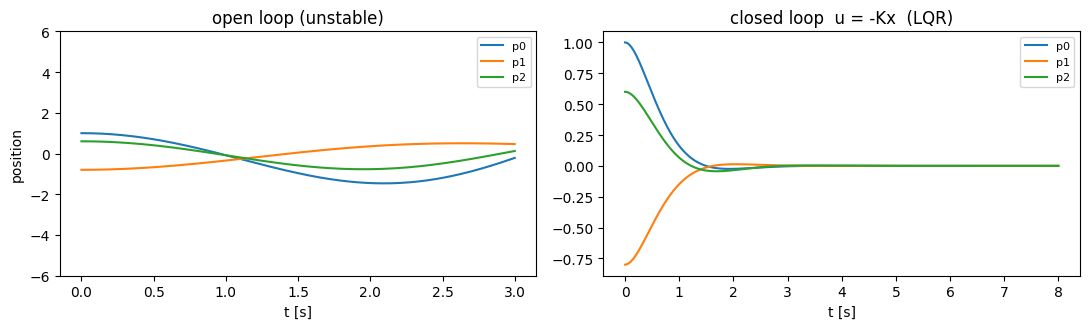

In [4]:
import matplotlib.pyplot as plt

K, X = lqr(A, B, Q, R)
ol = sorted(np.linalg.eigvals(A).real)
cl = sorted(np.linalg.eigvals(A - B @ K).real)
print("open-loop  eig real parts:", np.round(ol, 3), " -> unstable:", any(e > 0 for e in ol))
print("closed-loop eig real parts:", np.round(cl, 3), " -> Hurwitz :", all(e < 0 for e in cl))

def simulate(M, x0, T, dt=0.01):
    xs = [x0.copy()]; ts = [0.0]; x = x0.copy()
    for _ in range(int(T/dt)):
        k1 = M@x; k2 = M@(x+0.5*dt*k1); k3 = M@(x+0.5*dt*k2); k4 = M@(x+dt*k3)
        x = x + dt/6*(k1 + 2*k2 + 2*k3 + k4); xs.append(x.copy()); ts.append(ts[-1]+dt)
    return np.array(ts), np.array(xs)

x0 = np.array([1.0, 0.0, -0.8, 0.0, 0.6, 0.0])
t1, Xol = simulate(A,        x0, T=3.0)
t2, Xcl = simulate(A - B@K,  x0, T=8.0)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for i in range(3): ax[0].plot(t1, Xol[:, 2*i], label=f'p{i}')
for i in range(3): ax[1].plot(t2, Xcl[:, 2*i], label=f'p{i}')
ax[0].set_title('open loop (unstable)'); ax[0].set_xlabel('t [s]'); ax[0].set_ylabel('position')
ax[0].set_ylim(-6, 6); ax[0].legend(fontsize=8)
ax[1].set_title('closed loop  u = -Kx  (LQR)'); ax[1].set_xlabel('t [s]'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7. Conformance against the C++ solver

Now the point of the whole exercise: the *same* synthesis, run by the
hand-written C++ (`libs/control/lqr.hpp`) through a tiny C-ABI shim
(`libs/control/bind/lqr_bench.cpp`), on the *same* $(A,B,Q,R)$. We build the shim,
load it, and compare its gain against both the Python reference and the scipy
oracle. Agreement to machine precision pins the implementations together — an
edit that changes either side's result breaks this cell.

In [5]:
import subprocess, ctypes, pathlib

root = pathlib.Path.cwd()
while not (root / 'libs' / 'control').exists() and root != root.parent:
    root = root.parent
bind = root / 'libs' / 'control' / 'bind'
build = root / 'build-ilqr-bind'
subprocess.run(['cmake', '-S', str(bind), '-B', str(build), '-DCMAKE_BUILD_TYPE=Release'],
               check=True, stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT)
subprocess.run(['cmake', '--build', str(build)], check=True,
               stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT)
lib_path = next(p for p in (build/'liblqr_bench.dylib', build/'liblqr_bench.so') if p.exists())
lib = ctypes.CDLL(str(lib_path))
lib.lqr_bench_dims.argtypes = [ctypes.POINTER(ctypes.c_int)] * 2
lib.lqr_bench_solve.argtypes = [ctypes.POINTER(ctypes.c_double)] * 5
lib.lqr_bench_solve.restype = ctypes.c_int

def cpp_lqr(A, B, Q, R):
    nx = ctypes.c_int(); nu = ctypes.c_int(); lib.lqr_bench_dims(nx, nu)
    assert (nx.value, nu.value) == (A.shape[0], B.shape[1]), (nx.value, nu.value)
    flat = lambda Mx: (ctypes.c_double * Mx.size)(*Mx.ravel())
    cK = (ctypes.c_double * (B.shape[1] * A.shape[0]))()
    if lib.lqr_bench_solve(flat(A), flat(B), flat(Q), flat(R), cK):
        raise RuntimeError("C++ LQR solver reported an error")
    return np.array(cK).reshape(B.shape[1], A.shape[0])

print('C++ shim built and loaded:', lib_path.name)

C++ shim built and loaded: liblqr_bench.dylib


In [ ]:
K_cpp = cpp_lqr(A, B, Q, R)
K_ref, _ = lqr(A, B, Q, R)
X_sp = sla.solve_continuous_are(A, B, Q, R); K_sp = np.linalg.solve(R, B.T @ X_sp)

d_ref = np.abs(K_cpp - K_ref).max()
d_sp  = np.abs(K_cpp - K_sp).max()
print(f"{'pair':30s}{'||dK||_max':>14s}")
print(f"{'C++  vs  Python reference':30s}{d_ref:>14.2e}")
print(f"{'C++  vs  scipy (oracle)':30s}{d_sp:>14.2e}")
ok = d_ref < 1e-9 and d_sp < 1e-8
print('\nCONFORMANCE:', 'PASSED' if ok else 'FAILED')

pair                              ||dK||_max
C++  vs  Python reference           1.83e-14
C++  vs  scipy (oracle)             1.15e-14

CONFORMANCE: PASSED


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/diego/Documents/University/lab/Controlled Descent Simulator/modeling/venv/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
    ~~~~~~~~^^
  File "/Users/diego/Documents/University/lab/Controlled Descent Simulator/modeling/venv/lib/python3.14/site-packages/ipykernel/kernelbase.py", line 584, in shell_channel_thread_main
    _, msg2 = self.session.feed_identities(msg, copy=False)
              ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/Users/diego/Documents/University/lab/Controlled Descent Simulator/modeling/venv/lib/python3.14/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/diego/Documents/University/lab/Controlled Descent 

## 8. What this gives us

We now have a **generic, vehicle-agnostic LQR synthesis** whose Python reference
(this notebook, the spec) and C++ implementation (`libs/control/lqr.hpp`, the
product) are **pinned together** by the conformance cell — future edits to either
side break the test if they drift. The C++ synthesis is used by the runtime
models *at initialisation*: each vehicle supplies its own **error dynamics**
$(A,B)$ and weights $(Q,R)$ — the hover-linearised, integrator-augmented model
that lives in the `model/` notebooks — and receives the gain $K$ back, computed
from the *current physical parameters* (so $K$ tracks the parameters instead of
being frozen at codegen time).

A dependency-free version of this certificate
(`libs/control/bind/lqr_conformance.py`, ctypes + stdlib only — no numpy, no
scipy) runs the C++ side and certifies the returned gain is a genuine optimum by
a **Lyapunov-stationarity** check: it solves
$A_{cl}^\top X + X A_{cl} = -(Q + K^\top R K)$ for the closed-loop cost matrix $X$
and verifies $\lVert K - R^{-1}B^\top X\rVert \approx 0$ with $X\succ0$ as the
Hurwitz witness. That is the CI-able gate required for every hand-written
controller (AGENTS.md golden rule 10).